In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 # for displaying the image
from PIL import Image # for processing the image
import tensorflow as tf # 
tf.random.set_seed(1234)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix
print("All the required libraries are imported!!")

All the required libraries are imported!!


In [45]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)


In [46]:
print(f"The size of x_train: {x_train.shape}")
print(f"The size of x_test: {x_test.shape}")
print(f"The size of y_train: {y_train.shape}")
print(f"The size of y_test: {y_test.shape}")

The size of x_train: (60000, 28, 28)
The size of x_test: (10000, 28, 28)
The size of y_train: (60000,)
The size of y_test: (10000,)


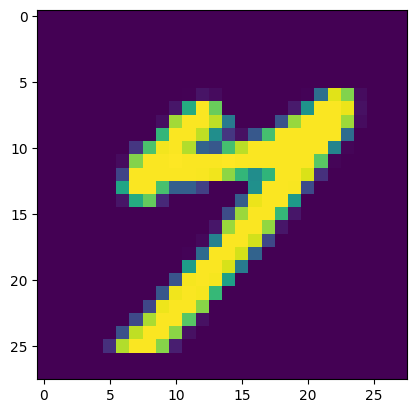

The image corresponding is : 7


In [16]:
# displaying a data point / image displaying


plt.imshow(x_train[1001])
plt.show()

# printing the corresponding ;abel

print(f"The image corresponding is : {y_train[1001]}")

In [18]:
# printing the unique values
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


Here the images are already resized if not we need to resixe the images using pil.resize()

In [47]:
# Now lets apply normalize to range of [0, 1] (not standardization)

x_train = x_train / 255
x_test = x_train / 255

In [20]:
print(x_train[1])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [27]:
# setting up the layers for the network

model = keras.Sequential(
    [
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(), # flatten the image to single dimension and give the size of image 28 * 28
        keras.layers.Dense(25, activation='relu'), # first layer of 25 neurons using Relu activation fucntion
        keras.layers.Dense(25, activation='relu'), # second layer of 25 neurons using Relu activation fucntion
        keras.layers.Dense(10, activation='sigmoid') # output must be the different classes [0, 1, 2, 3, ... 9]
            
        
        
    ]
)

print("The model is set!!")

The model is set!!


In [34]:
# compling the model

model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("The model is compiled!!")

The model is compiled!!


In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,535 (80.21 KB)

 Trainable params: 20,535 (80.21 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# training the model

history = model.fit(x_train, y_train, epochs=10 )


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8928 - loss: 0.3733
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9458 - loss: 0.1860
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9557 - loss: 0.1502
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9618 - loss: 0.1290
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9665 - loss: 0.1132
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9697 - loss: 0.1014
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9724 - loss: 0.0920
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9744 - loss: 0.0846
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0785
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9782 - loss: 0.0731


In [48]:
print(x_test.shape, y_test.shape)

(60000, 28, 28) (10000,)


In [41]:
# training data accuracy is 97.82 % 

# accuracy of the training data


loss, accuracy = model.evaluate(x_test, y_test)

print(f"The accuracy : {accuracy * 100}%")
print(f"The loss : {loss * 100}%")

(60000, 28, 28) (60000,)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 60000
'y' sizes: 10000
